# Rapport analytique - Musées, Artistes, Œuvres (base Joconde nettoyée)
## Projet NoSQL & Big Data - Neo4j

Ce notebook travaille sur les données **déjà nettoyées** (`../data/oeuvres_clean.csv` + les 3 fichiers Wikidata) - pas sur le fichier brut `joconde.csv`. Pour la procédure d'exploration/nettoyage en amont, voir `PROCEDURE_EDA.md` (résumé) ou `eda_joconde.ipynb` (détail exécuté).

**Objectif** : produire les premières réponses aux questions métier du projet à partir de pandas/networkx, avant même que l'import Neo4j (Rémi) soit terminé. Ce n'est pas un remplacement de l'analyse en graphe (Cypher + GDS feront mieux à pleine échelle), mais un aperçu qui ne dépend de personne d'autre et qui alimente déjà le rapport analytique demandé par le sujet.

Notebook non nettoyé/non condensé, comme le premier : les limites de couverture sont montrées, pas cachées.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid")

## 1. Chargement des données propres

In [2]:
oeuvres = pd.read_csv("../data/oeuvres_clean.csv")
artistes_wd = pd.read_csv("../data/artistes_wikidata.csv")
influences = pd.read_csv("../data/rel_influence_par.csv")
mouvements = pd.read_csv("../data/artistes_mouvement.csv")

print("oeuvres          :", oeuvres.shape)
print("artistes_wikidata:", artistes_wd.shape)
print("influences       :", influences.shape)
print("mouvements       :", mouvements.shape)

oeuvres          : (137474, 17)
artistes_wikidata: (150, 6)
influences       : (56, 2)
mouvements       : (77, 2)


## 2. Vue d'ensemble du corpus retenu

Rappel de la procédure de nettoyage (détaillée dans `PROCEDURE_EDA.md`) : 137 474 œuvres, filtrées sur le domaine (peinture/sculpture/beaux-arts) et sur les auteurs nommés (anonymes exclus).

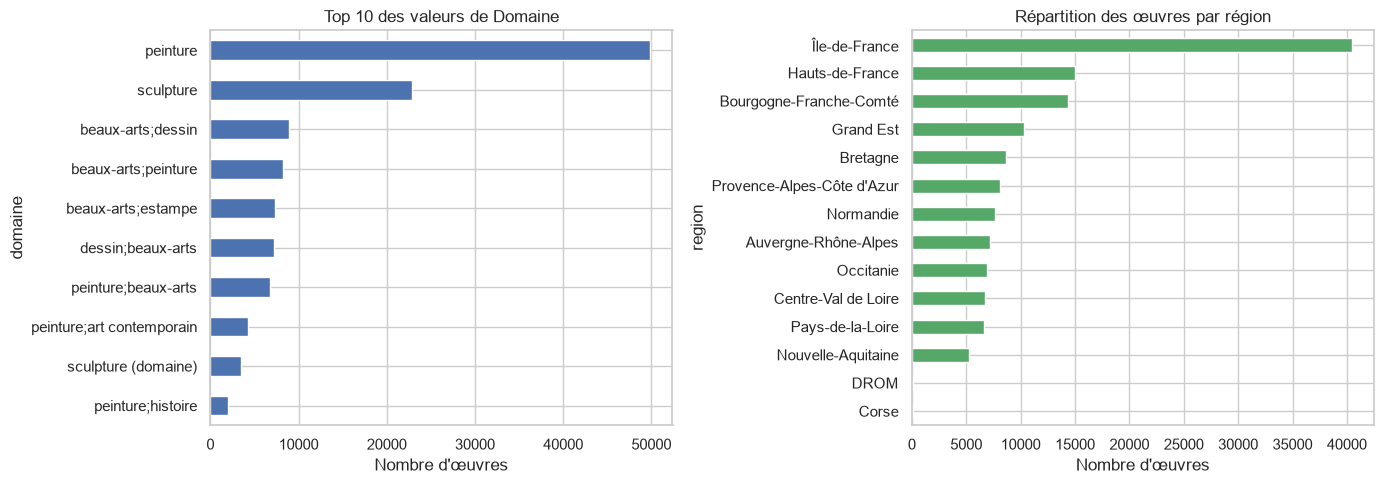

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

oeuvres["domaine"].value_counts().head(10).plot(kind="barh", ax=axes[0], color="#4C72B0")
axes[0].invert_yaxis()
axes[0].set_title("Top 10 des valeurs de Domaine")
axes[0].set_xlabel("Nombre d'œuvres")

oeuvres["region"].value_counts().plot(kind="barh", ax=axes[1], color="#55A868")
axes[1].invert_yaxis()
axes[1].set_title("Répartition des œuvres par région")
axes[1].set_xlabel("Nombre d'œuvres")

plt.tight_layout()
plt.show()

Sans surprise, l'Île-de-France domine largement (musées parisiens très représentés dans Joconde) - à garder en tête pour ne pas surinterpréter les questions "un mouvement est-il concentré dans telle région" : une partie de la concentration vient simplement de la sous-représentation générale des autres régions dans le corpus, pas forcément d'un vrai effet du mouvement.

## 3. Carte simplifiée des musées

Les coordonnées GPS sont déjà présentes et propres à 99,8% (voir procédure de nettoyage) - pas de géocodage à faire. On visualise ici la localisation des musées, avec une taille de point proportionnelle au nombre d'œuvres qu'ils contiennent dans notre sous-ensemble.

In [4]:
musees = (
    oeuvres.dropna(subset=["lat", "lon"])
    .groupby(["nom_musee", "region"], as_index=False)
    .agg(lat=("lat", "first"), lon=("lon", "first"), nb_oeuvres=("id_oeuvre", "count"))
)
print(f"{len(musees)} musées géolocalisés")
musees.sort_values("nb_oeuvres", ascending=False).head(10)

474 musées géolocalisés


,nom_musee,region,lat,lon,nb_oeuvres
377,musée du Louvre,Île-de-France,48.860795,2.337816,8063
346,musée des beaux-arts,Bretagne,47.996188,-4.101963,7167
160,musée Rodin,Île-de-France,48.855868,2.315980,6298
456,musée national des châteaux de Versailles et d...,Île-de-France,48.804537,2.134053,4384
359,musée des beaux-arts et d'archéologie,Bourgogne-Franche-Comté,47.089059,5.488205,4120
79,musée Carnavalet - histoire de Paris,Île-de-France,48.856990,2.362856,3671
350,musée des beaux-arts,Normandie,49.444958,1.093908,3633
282,musée de la Chartreuse,Hauts-de-France,50.374404,3.075480,3546
206,musée d'Orsay,Île-de-France,48.859157,2.323672,3429
364,musée des beaux-arts et galerie David-d'Angers,Pays-de-la-Loire,47.469659,-0.555485,2801


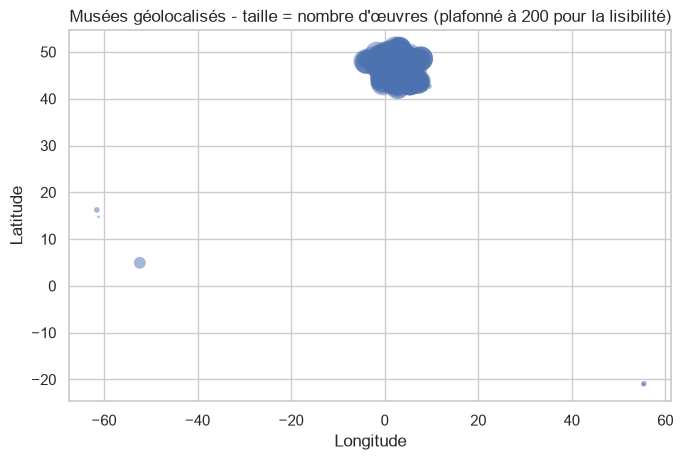

In [5]:
fig, ax = plt.subplots(figsize=(7, 8))
scatter = ax.scatter(
    musees["lon"], musees["lat"],
    s=musees["nb_oeuvres"].clip(upper=200) * 1.5,
    alpha=0.5, c="#4C72B0", edgecolors="none",
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Musées géolocalisés - taille = nombre d'œuvres (plafonné à 200 pour la lisibilité)")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 4. Couverture réelle du rapprochement Wikidata

Le rapprochement Wikidata (influence, mouvement) n'a été fait que sur les **150 graphies d'auteur les plus fréquentes** - pas sur les 39 315 graphies distinctes du sous-ensemble beaux-arts. Avant d'aller plus loin, on mesure honnêtement quelle part du corpus ces 150 artistes représentent réellement.

In [6]:
noms_top150 = set(artistes_wd["auteur_joconde"])
oeuvres["a_un_artiste_top150"] = oeuvres["auteur_brut"].isin(noms_top150)

nb_couvert = oeuvres["a_un_artiste_top150"].sum()
print(f"Œuvres dont l'auteur est dans le top 150 Wikidata : {nb_couvert:,} / {len(oeuvres):,} ({nb_couvert/len(oeuvres)*100:.1f}%)")

nb_trouve_wikidata = artistes_wd["trouve"].sum()
print(f"Sur ces 150 artistes, {nb_trouve_wikidata} ont effectivement été retrouvés sur Wikidata (QID identifié)")

Œuvres dont l'auteur est dans le top 150 Wikidata : 39,886 / 137,474 (29.0%)
Sur ces 150 artistes, 114 ont effectivement été retrouvés sur Wikidata (QID identifié)


**Constat à ne pas perdre de vue pour la suite du projet** : même en couvrant les 150 artistes les plus prolifiques, on ne couvre qu'une fraction du corpus - la distribution des auteurs a une longue traîne (beaucoup d'artistes avec très peu d'œuvres chacun). Les analyses d'influence/mouvement ci-dessous portent donc sur ce sous-ensemble couvert, pas sur la totalité des 137 474 œuvres. C'est une limite à assumer explicitement dans le rapport final, pas à cacher.

## 5. Un mouvement artistique donné est-il concentré géographiquement ?

Jointure : `oeuvres.auteur_brut` → `artistes_wikidata.auteur_joconde` → `label_wikidata` → `artistes_mouvement.artiste`.

In [7]:
oeuvres_avec_artiste = oeuvres.merge(
    artistes_wd[["auteur_joconde", "label_wikidata"]],
    left_on="auteur_brut", right_on="auteur_joconde", how="inner",
)
oeuvres_mouvement = oeuvres_avec_artiste.merge(
    mouvements, left_on="label_wikidata", right_on="artiste", how="inner",
)
print(f"Œuvres reliées à un mouvement connu : {len(oeuvres_mouvement):,}")
oeuvres_mouvement[["titre", "label_wikidata", "mouvement", "region"]].head(10)

Œuvres reliées à un mouvement connu : 40,018


,titre,label_wikidata,mouvement,region
0,PAYSAGE DE TAHITI,Henri Matisse,impressionnisme,Provence-Alpes-Côte d'Azur
1,PAYSAGE DE TAHITI,Henri Matisse,néo-impressionnisme,Provence-Alpes-Côte d'Azur
2,PAYSAGE DE TAHITI,Henri Matisse,postimpressionnisme,Provence-Alpes-Côte d'Azur
3,PAYSAGE DE TAHITI,Henri Matisse,fauvisme,Provence-Alpes-Côte d'Azur
4,PAYSAGE DE TAHITI,Henri Matisse,divisionnisme,Provence-Alpes-Côte d'Azur
5,PORTRAIT DE DANSEUSE ESPAGNOLE,Henri Matisse,impressionnisme,Provence-Alpes-Côte d'Azur
6,PORTRAIT DE DANSEUSE ESPAGNOLE,Henri Matisse,néo-impressionnisme,Provence-Alpes-Côte d'Azur
7,PORTRAIT DE DANSEUSE ESPAGNOLE,Henri Matisse,postimpressionnisme,Provence-Alpes-Côte d'Azur
8,PORTRAIT DE DANSEUSE ESPAGNOLE,Henri Matisse,fauvisme,Provence-Alpes-Côte d'Azur
9,PORTRAIT DE DANSEUSE ESPAGNOLE,Henri Matisse,divisionnisme,Provence-Alpes-Côte d'Azur


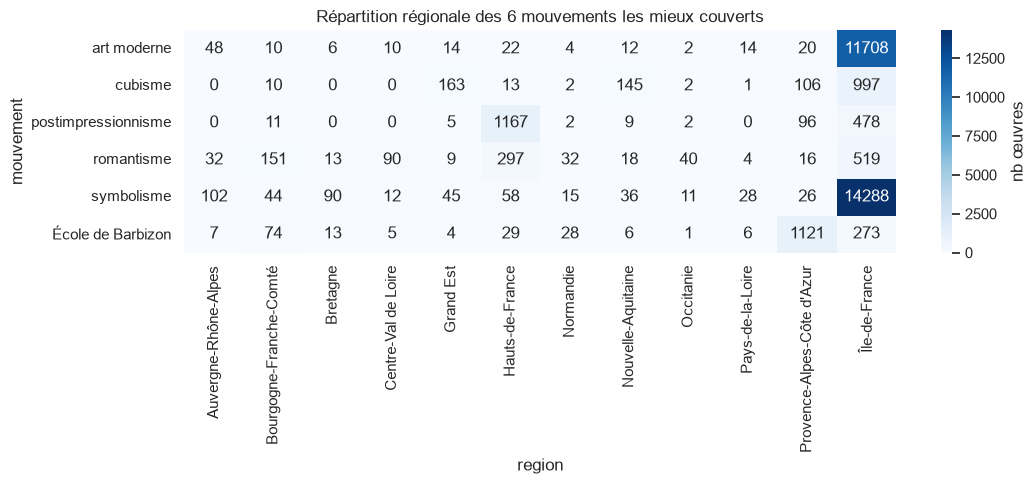

In [8]:
repartition = (
    oeuvres_mouvement.groupby(["mouvement", "region"]).size()
    .reset_index(name="nb_oeuvres")
)

top_mouvements = oeuvres_mouvement["mouvement"].value_counts().head(6).index
pivot = (
    repartition[repartition["mouvement"].isin(top_mouvements)]
    .pivot(index="mouvement", columns="region", values="nb_oeuvres")
    .fillna(0)
)
fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="Blues", ax=ax, cbar_kws={"label": "nb œuvres"})
ax.set_title("Répartition régionale des 6 mouvements les mieux couverts")
plt.tight_layout()
plt.show()

Sur ce sous-ensemble encore restreint, difficile de conclure fermement à une vraie concentration géographique propre à un mouvement plutôt qu'à l'effet dominant de l'Île-de-France déjà observé en section 2 sur l'ensemble du corpus. Une réponse solide à cette question demandera le graphe complet dans Neo4j (plus de mouvements, plus d'œuvres, et surtout une vraie mesure de dispersion plutôt qu'une lecture visuelle).

## 6. Réseau d'influence - aperçu avec networkx

56 relations d'influence sur 24 artistes seulement (voir couverture, section 4) - trop peu pour des conclusions définitives, mais suffisant pour un premier graphe et une démonstration de ce que Neo4j + GDS pourra faire à pleine échelle.

In [9]:
G = nx.from_pandas_edgelist(
    influences, source="artiste", target="influenceur", create_using=nx.DiGraph
)
print(f"{G.number_of_nodes()} nœuds, {G.number_of_edges()} relations d'influence")

60 nœuds, 54 relations d'influence


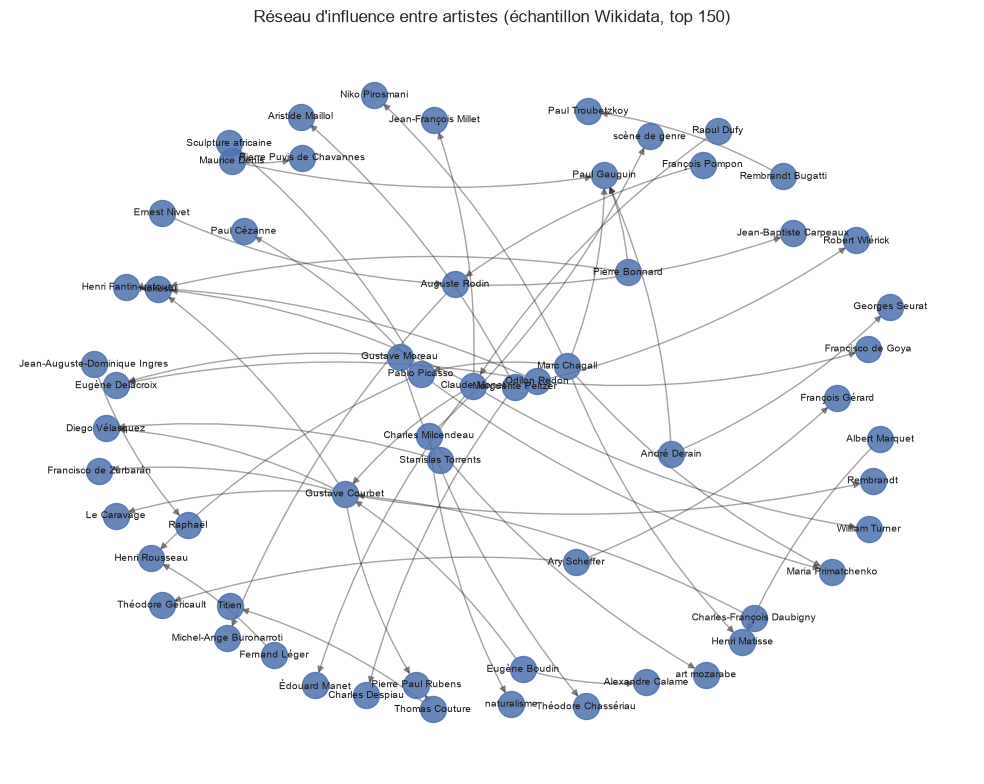

In [10]:
fig, ax = plt.subplots(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42, k=0.9)
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=350, node_color="#4C72B0", alpha=0.85)
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowsize=10, alpha=0.4, connectionstyle="arc3,rad=0.1")
nx.draw_networkx_labels(G, pos, ax=ax, font_size=7)
ax.set_title("Réseau d'influence entre artistes (échantillon Wikidata, top 150)")
ax.axis("off")
plt.tight_layout()
plt.show()

In [11]:
in_degree = dict(G.in_degree())  # nombre d'artistes qui influencent CET artiste
out_degree = dict(G.out_degree())  # nombre d'entités que CET artiste a influencées / par qui il est influencé selon le sens choisi

print("Artistes les plus 'influencés' (le plus grand nombre d'influenceurs déclarés) :")
top_influences = sorted(in_degree.items(), key=lambda x: -x[1])[:5]
for nom, deg in top_influences:
    if deg > 0:
        print(f"  {nom} : {deg} influenceur(s)")

Artistes les plus 'influencés' (le plus grand nombre d'influenceurs déclarés) :
  Paul Gauguin : 4 influenceur(s)
  Gustave Courbet : 3 influenceur(s)
  Hokusai : 3 influenceur(s)
  Auguste Rodin : 2 influenceur(s)
  Maria Primatchenko : 2 influenceur(s)


In [12]:
pagerank = nx.pagerank(G)
top_pagerank = sorted(pagerank.items(), key=lambda x: -x[1])[:8]
print("Top 8 par PageRank (centralité dans ce petit réseau) :")
for nom, score in top_pagerank:
    print(f"  {nom:35s} {score:.4f}")

Top 8 par PageRank (centralité dans ce petit réseau) :
  Auguste Rodin                       0.0321
  Gustave Courbet                     0.0308
  Paul Gauguin                        0.0291
  Diego Vélasquez                     0.0264
  Jean-Baptiste Carpeaux              0.0255
  Michel-Ange Buronarroti             0.0255
  Hokusai                             0.0251
  Henri Rousseau                      0.0250


Aperçu volontairement modeste : avec seulement 56 relations, le PageRank ici n'a pas la même valeur statistique qu'il aura une fois calculé par Neo4j GDS sur le graphe complet (des milliers d'artistes potentiellement, si on étend le rapprochement Wikidata au-delà du top 150). L'intérêt de cette section est de montrer que le calcul et la visualisation fonctionnent déjà sur un échantillon, pas de tirer des conclusions définitives sur "qui est l'artiste le plus influent".

In [13]:
# Existe-t-il un chemin d'influence entre deux artistes connus dans notre petit échantillon ?
artistes_connus = list(G.nodes)
essais = [("Pablo Picasso", "Auguste Rodin"), ("Auguste Rodin", "Pablo Picasso")]
for a, b in essais:
    if a in G and b in G:
        chemin = nx.shortest_path(G, a, b) if nx.has_path(G, a, b) else None
        print(f"{a} -> {b} : {' -> '.join(chemin) if chemin else 'aucun chemin dans cet échantillon'}")
    else:
        print(f"{a} -> {b} : au moins un des deux n'est pas dans ce petit réseau (56 relations seulement)")

Pablo Picasso -> Auguste Rodin : aucun chemin dans cet échantillon
Auguste Rodin -> Pablo Picasso : aucun chemin dans cet échantillon


Sans surprise sur un réseau aussi petit (56 relations), il n'y a pas forcément de chemin entre deux artistes choisis au hasard - la démonstration de vraies chaînes d'influence à plusieurs sauts aura besoin du graphe complet dans Neo4j. Ce qu'on retient ici, c'est que la mécanique (`nx.shortest_path`, l'équivalent de `shortestPath()` en Cypher) fonctionne et donne un aperçu de ce que Neo4j fera passer à l'échelle.

## 7. Répartition des œuvres d'un même artiste entre musées et régions

In [14]:
par_artiste = (
    oeuvres.groupby("auteur_brut")
    .agg(nb_oeuvres=("id_oeuvre", "count"), nb_musees=("code_museofile", "nunique"), nb_regions=("region", "nunique"))
    .sort_values("nb_oeuvres", ascending=False)
)
print("Top 10 des artistes les plus représentés dans le corpus :")
par_artiste.head(10)

Top 10 des artistes les plus représentés dans le corpus :


,nb_oeuvres,nb_musees,nb_regions
auteur_brut,,,
Rodin Auguste (1840-1917),5812,37,12
Henner Jean-Jacques (1829-1905),1537,23,8
Ziem Félix (1821-1911),1323,30,11
David d'Angers Pierre-Jean (1788-1856),1114,24,12
Bouchard Henri (1875-1960),1019,7,4
Nivet Ernest (1871-1948),969,2,1
Frélaut Jean (1879-1954),864,2,2
Lansyer Emmanuel (1835-1893),810,3,2
Duhem Henri (1860-1941),754,2,2


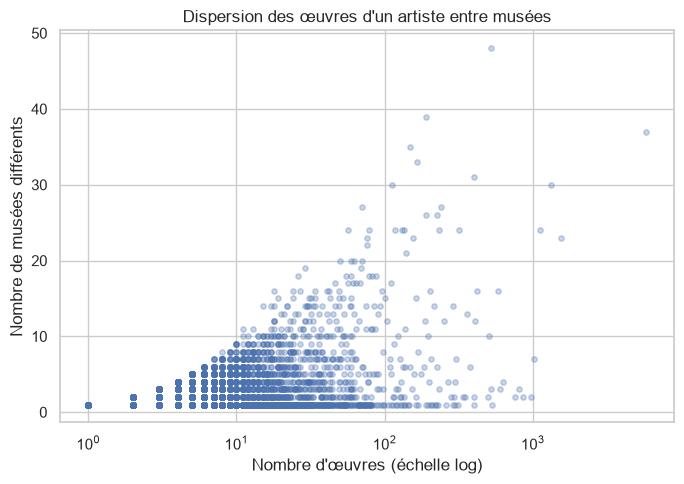

In [15]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(par_artiste["nb_oeuvres"], par_artiste["nb_musees"], alpha=0.3, s=15)
ax.set_xscale("log")
ax.set_xlabel("Nombre d'œuvres (échelle log)")
ax.set_ylabel("Nombre de musées différents")
ax.set_title("Dispersion des œuvres d'un artiste entre musées")
plt.tight_layout()
plt.show()

On voit une tendance attendue : plus un artiste a d'œuvres dans le corpus, plus elles sont dispersées dans un grand nombre de musées différents - mais avec une variance importante (certains artistes très prolifiques restent concentrés dans un ou deux musées, typiquement leur musée dédié ou leur ville d'origine). Une lecture plus fine par artiste nommé sera possible une fois le graphe interrogeable en Cypher.

## 8. Synthèse - ce que ce notebook répond déjà, ce qui attend Neo4j

| Question métier | Réponse possible dès maintenant (pandas/networkx) | Ce qui nécessite le graphe complet (Neo4j + GDS) |
|---|---|---|
| Répartition géographique du corpus | Oui - section 2 (Île-de-France très dominante) | Affiner avec la hiérarchie Ville→Département→Région en Cypher |
| Carte des musées | Oui - section 3 | Carte interactive dans la WebApp |
| Couverture du rapprochement Wikidata | Oui, mesurée honnêtement - section 4 | Étendre le rapprochement au-delà du top 150 |
| Mouvement concentré géographiquement ? | Aperçu limité (peu de mouvements couverts) - section 5 | Réponse solide avec plus d'artistes/mouvements et une vraie mesure de dispersion |
| Artiste le plus "central"/influent | Aperçu sur 56 relations (PageRank networkx) - section 6 | PageRank/Louvain GDS sur le graphe complet |
| Chemin d'influence entre deux artistes | Mécanique démontrée, mais réseau trop petit pour des chemins réels - section 6 | `shortestPath()` Cypher sur un graphe d'influence plus riche |
| Répartition des œuvres d'un artiste | Oui - section 7 | Requêtes Cypher équivalentes, exploitables dans la WebApp |

Ce notebook constitue donc un premier jet de rapport analytique, indépendant de l'avancement de l'import Neo4j. Une fois Rémi opérationnel, les sections 5 et 6 seront reprises avec de vraies requêtes Cypher/GDS sur l'intégralité du graphe plutôt que sur cet échantillon.